# Prompted Generation, Classifier-Free Guidance, and Latent Diffusion

The decisive step from unconditional image generation to modern prompting is the move from modeling $p(\boldsymbol{x})$ to modeling a conditional distribution such as $p(\boldsymbol{x}|\boldsymbol{c})$, where $\boldsymbol{c}$ is a representation of side information. In the simplest cases, that side information is a class label. In contemporary image systems, it is much more often a text embedding produced by a language model. Once that embedding is injected into every denoising step, diffusion becomes a controllable generator rather than a purely unconditional sampler.

On `FashionMNIST`, the whole mechanism can be made explicit without hiding any of the important ingredients. A small pretrained text encoder can turn prompts such as “generate an image of a boot” or “draw a handbag” into dense semantic vectors. A diffusion denoiser can then be trained to use those vectors during every reverse step. The same logic extends naturally to **classifier-free guidance**, where conditional and unconditional predictions are mixed at sampling time, and then to **latent diffusion**, where denoising is performed in the latent space of a variational autoencoder rather than directly in pixel space.

The latent-diffusion side of the notebook follows the same structural idea that made large text-to-image systems practical in {cite}`rombach2022high`.

The presentation below follows the same rhythm used in the stronger VAE and GAN notebooks. Each modeling idea is discussed first at the conceptual level and is then implemented immediately afterward. The first half of the notebook trains a text-conditioned diffusion model in pixel space using a frozen pretrained text encoder. The second half trains a **VAE** and then performs text-conditioned diffusion in that VAE latent space, so the full **latent diffusion** pipeline is present and operational on `FashionMNIST`.

```{important}
In prompted diffusion, the prompt is not consumed once at the beginning and then forgotten. Its embedding shapes **every denoising update** of the reverse trajectory.
```

## Text Conditioning and Classifier-Free Guidance

A conditional diffusion model replaces the unconditional denoiser
:::{math}
\boldsymbol{\varepsilon}_\theta(\boldsymbol{x}_t,t)
:::
with a conditioned denoiser
:::{math}
\boldsymbol{\varepsilon}_\theta(\boldsymbol{x}_t,t,\boldsymbol{c}),
:::
where $\boldsymbol{c}$ is now a prompt embedding. This changes the modeling task in a very precise way. The network is no longer asked only to reverse Gaussian corruption. It is asked to reverse Gaussian corruption **while staying aligned with a requested semantic description**. A prompt such as “generate an image of a boot” should keep pushing the reverse trajectory toward the region of the data distribution associated with ankle boots, while a prompt such as “draw a handbag” should steer the same denoiser toward bags.

**Classifier-free guidance** sharpens this conditioning signal without requiring a second model. During training, part of the minibatch is given a null prompt, so the same network learns both a conditional and an unconditional behavior. During sampling, the two outputs are combined through
:::{math}
\boldsymbol{\varepsilon}_{guided}
=
\boldsymbol{\varepsilon}_{uncond}
+
\omega\left(
\boldsymbol{\varepsilon}_{cond}-\boldsymbol{\varepsilon}_{uncond}
\right),
:::
where $\omega$ is the guidance scale. This equation says exactly what the sampler is doing: start from the unconditional denoising direction and then move further toward the prompt-consistent direction. Larger guidance usually improves prompt adherence, although it may also reduce diversity if pushed too far.

This guidance mechanism is the classifier-free guidance strategy introduced by Ho and Salimans {cite}`ho2022classifierfree`.

### A Pretrained Tiny Text Encoder and a Prompt Corpus

To make conditioning realistic, the prompt embeddings below are produced by a **pretrained tiny BERT encoder** rather than by a prompt model trained from scratch inside the notebook. That is much closer to the structure used in modern image systems: the text model and the image denoiser play different roles. The text encoder builds a semantic representation of the prompt, and the diffusion model learns how that representation should shape the reverse trajectory.

The prompt corpus is still deliberately compact because `FashionMNIST` has only ten semantic classes, but the prompts are written as short natural-language requests rather than as class IDs. This keeps the notebook honest about what prompting actually means: text is tokenized, encoded by a language model, pooled into an embedding, and then injected into the denoiser. The underlying language-encoder idea comes from pretrained transformer encoders such as BERT {cite}`devlin2019bert`.

In [2]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchvision import datasets, transforms, utils
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(7)
torch.manual_seed(7)
if device.type == "cuda":
    torch.cuda.manual_seed_all(7)

project_root = Path.cwd() if (Path.cwd() / "_config.yml").exists() else Path.cwd().parent
artifacts_dir = project_root / "artifacts"
artifacts_dir.mkdir(exist_ok=True)

batch_size = 128
metric_batch_size = 64
num_workers = 0
image_size = 28
channels = 1
timesteps = 300
base_channels = 64
time_dim = 128
text_dim = 128
conditional_epochs = 45
vae_epochs = 35
latent_diffusion_epochs = 45
condition_dropout = 0.15
latent_channels = 8
latent_scaling = 0.18215
text_model_name = "prajjwal1/bert-tiny"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 2.0 * x - 1.0),
])

train_dataset = datasets.FashionMNIST(root=project_root / "data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root=project_root / "data", train=False, download=True, transform=transform)
class_names = train_dataset.classes


In [3]:
prompt_bank = {
    0: [
        "generate an image of a tshirt",
        "draw a casual tshirt",
        "show a short sleeve top",
    ],
    1: [
        "generate an image of trousers",
        "draw a pair of pants",
        "show a pair of trousers",
    ],
    2: [
        "generate an image of a pullover",
        "draw a knitted pullover",
        "show a warm sweater",
    ],
    3: [
        "generate an image of a dress",
        "draw a simple dress",
        "show a clothing dress",
    ],
    4: [
        "generate an image of a coat",
        "draw a long coat",
        "show a winter coat",
    ],
    5: [
        "generate an image of a sandal",
        "draw an open sandal",
        "show a summer sandal",
    ],
    6: [
        "generate an image of a shirt",
        "draw a collared shirt",
        "show a shirt garment",
    ],
    7: [
        "generate an image of a sneaker",
        "draw a sport sneaker",
        "show a sneaker shoe",
    ],
    8: [
        "generate an image of a bag",
        "draw a handbag",
        "show a fashion bag",
    ],
    9: [
        "generate an image of a boot",
        "draw an ankle boot",
        "show a boot shoe",
    ],
}

all_prompts = [prompt for prompts in prompt_bank.values() for prompt in prompts]
null_prompt = ""

class PromptedFashionDataset(Dataset):
    def __init__(self, base_dataset, prompt_bank):
        self.base_dataset = base_dataset
        self.prompt_bank = prompt_bank

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        prompt = random.choice(self.prompt_bank[label])
        return image, label, prompt


def prompt_collate(batch):
    images, labels, prompts = zip(*batch)
    images = torch.stack(images)
    labels = torch.tensor(labels, dtype=torch.long)
    return images, labels, list(prompts)


prompt_train_dataset = PromptedFashionDataset(train_dataset, prompt_bank)
prompt_test_dataset = PromptedFashionDataset(test_dataset, prompt_bank)

prompt_train_loader = DataLoader(
    prompt_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
    collate_fn=prompt_collate,
)
prompt_test_loader = DataLoader(
    prompt_test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
    collate_fn=prompt_collate,
)


In [4]:
tokenizer = AutoTokenizer.from_pretrained(text_model_name, use_fast=False)
text_encoder = AutoModel.from_pretrained(text_model_name).to(device)
text_encoder.eval()
for parameter in text_encoder.parameters():
    parameter.requires_grad_(False)


def mean_pool(hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    masked = hidden_state * mask
    return masked.sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)


@torch.no_grad()
def encode_prompts(prompts):
    encoded = tokenizer(
        prompts,
        padding=True,
        truncation=True,
        return_tensors="pt",
    )
    encoded = {key: value.to(device) for key, value in encoded.items()}
    outputs = text_encoder(**encoded)
    pooled = mean_pool(outputs.last_hidden_state, encoded["attention_mask"])
    return pooled


sample_prompt_embeddings = encode_prompts([
    "generate an image of a boot",
    "draw a handbag",
    "show a winter coat",
])
print(sample_prompt_embeddings.shape)


vocab.txt: 0.00B [00:00, ?B/s]

c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tivog\.cache\huggingface\hub\models--prajjwal1--bert-tiny. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\transformers\tokenization_utils_base.py:160

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


torch.Size([3, 128])


### A Text-Conditioned Diffusion Denoiser

The denoiser combines a sinusoidal time embedding with the pretrained prompt embedding. In architectural terms, nothing magical is happening: the prompt vector and the time vector are projected to the same dimension, added together, and injected into residual blocks throughout a compact U-Net. What matters is not complexity for its own sake, but the fact that the reverse dynamics now have access to a genuine semantic signal derived from text.

On `FashionMNIST`, this is enough to make prompted generation concrete. The prompt “generate an image of a boot” is not reduced to a hard-coded class index inside the denoiser. It is first embedded by a frozen pretrained language model, and the diffusion model learns how to use that semantic vector during denoising.

In [5]:
betas = torch.linspace(1e-4, 0.02, timesteps, device=device)
bar_alphas = 1.0 - betas
alphas = torch.cumprod(bar_alphas, dim=0)
alphas_prev = torch.cat([torch.tensor([1.0], device=device), alphas[:-1]], dim=0)

sqrt_alphas = torch.sqrt(alphas)
sqrt_one_minus_alphas = torch.sqrt(1.0 - alphas)
sqrt_recip_bar_alphas = torch.sqrt(1.0 / bar_alphas)
posterior_variance = betas * (1.0 - alphas_prev) / (1.0 - alphas)


def extract(coefficients, t, x_shape):
    out = coefficients.gather(0, t)
    return out.view(t.shape[0], *((1,) * (len(x_shape) - 1)))


def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    return (
        extract(sqrt_alphas, t, x0.shape) * x0
        + extract(sqrt_one_minus_alphas, t, x0.shape) * noise
    )


class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        factor = math.log(10000.0) / max(half - 1, 1)
        frequencies = torch.exp(torch.arange(half, device=t.device) * -factor)
        angles = t.float().unsqueeze(1) * frequencies.unsqueeze(0)
        embedding = torch.cat([angles.sin(), angles.cos()], dim=1)
        if self.dim % 2 == 1:
            embedding = F.pad(embedding, (0, 1))
        return embedding


class ConditionalResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, context_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.context_proj = nn.Linear(context_dim, out_channels)
        self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, context):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.context_proj(context)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class TextConditionedUNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=64, time_dim=128, text_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.input_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)
        self.down1 = ConditionalResidualBlock(base_channels, base_channels, time_dim)
        self.downsample = nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.mid1 = ConditionalResidualBlock(base_channels * 2, base_channels * 2, time_dim)
        self.mid2 = ConditionalResidualBlock(base_channels * 2, base_channels * 2, time_dim)
        self.upsample = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1)
        self.up1 = ConditionalResidualBlock(base_channels * 2, base_channels, time_dim)
        self.output_conv = nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1)

    def forward(self, x, t, prompt_embedding):
        time_context = self.time_mlp(t)
        text_context = self.text_proj(prompt_embedding)
        context = time_context + text_context
        x0 = self.input_conv(x)
        x1 = self.down1(x0, context)
        x2 = self.downsample(x1)
        x2 = self.mid1(x2, context)
        x2 = self.mid2(x2, context)
        x3 = self.upsample(x2)
        x3 = torch.cat([x3, x1], dim=1)
        x3 = self.up1(x3, context)
        return self.output_conv(x3)


text_denoiser = TextConditionedUNet(in_channels=channels, base_channels=base_channels, time_dim=time_dim, text_dim=text_dim).to(device)


### Training the Prompted Diffusion Model

The training objective remains the standard DDPM noise-prediction loss. The prompt mechanism changes neither the forward corruption law nor the regression target. What it changes is the context available to the denoiser. Prompt dropout implements classifier-free guidance by replacing a fraction of the prompts with the empty string, which is then encoded by the same pretrained text encoder. The denoiser therefore learns an unconditional branch and a conditional branch inside a single network.

In [6]:
def apply_prompt_dropout(prompts, dropout_prob=0.0):
    if dropout_prob == 0.0:
        return prompts
    dropped = []
    for prompt in prompts:
        if random.random() < dropout_prob:
            dropped.append(null_prompt)
        else:
            dropped.append(prompt)
    return dropped


def conditional_diffusion_loss(model, images, prompts):
    t = torch.randint(0, timesteps, (images.size(0),), device=images.device).long()
    noise = torch.randn_like(images)
    xt = q_sample(images, t, noise=noise)
    prompt_embedding = encode_prompts(apply_prompt_dropout(prompts, dropout_prob=condition_dropout))
    pred_noise = model(xt, t, prompt_embedding)
    return F.mse_loss(pred_noise, noise)


In [7]:
text_denoiser_optimizer = torch.optim.Adam(text_denoiser.parameters(), lr=2e-4)
text_history = []

for epoch in range(conditional_epochs):
    text_denoiser.train()
    running = 0.0
    progress = tqdm(prompt_train_loader, desc=f"text diffusion epoch {epoch + 1}/{conditional_epochs}", leave=False)
    for images, labels, prompts in progress:
        images = images.to(device)
        loss = conditional_diffusion_loss(text_denoiser, images, prompts)

        text_denoiser_optimizer.zero_grad()
        loss.backward()
        text_denoiser_optimizer.step()

        running += loss.item() * images.size(0)
        progress.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running / len(prompt_train_loader.dataset)
    text_history.append(epoch_loss)
    print(f"epoch {epoch + 1:02d} | text diffusion loss = {epoch_loss:.4f}")

torch.save(
    {
        "denoiser": text_denoiser.state_dict(),
        "text_model_name": text_model_name,
    },
    artifacts_dir / "text_conditioned_diffusion_fashionmnist.pt",
)


text diffusion epoch 1/45:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 01 | text diffusion loss = 0.1400


text diffusion epoch 2/45:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 02 | text diffusion loss = 0.0917


text diffusion epoch 3/45:   0%|          | 0/469 [00:00<?, ?it/s]

...

epoch 43 | text diffusion loss = 0.0671


text diffusion epoch 44/45:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 44 | text diffusion loss = 0.0665


text diffusion epoch 45/45:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 45 | text diffusion loss = 0.0674


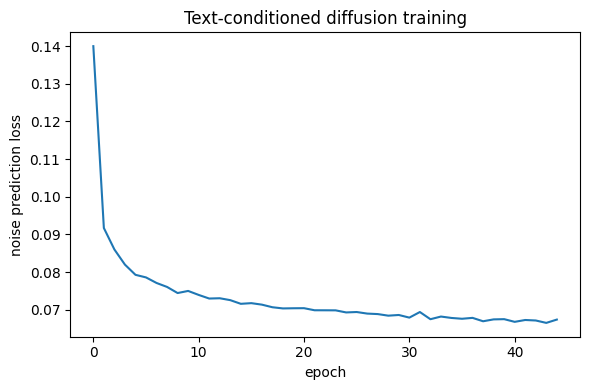

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(text_history)
plt.xlabel("epoch")
plt.ylabel("noise prediction loss")
plt.title("Text-conditioned diffusion training")
plt.tight_layout()
plt.show()


### Guided Sampling from Natural-Language Prompts

At sampling time the prompts are encoded twice: once as written and once as the empty prompt. The two denoising predictions are then mixed through the classifier-free guidance formula. This makes the effect of prompting visible in exactly the same mathematical form described earlier. The only difference from class-conditioned diffusion is that the conditioning vector now comes from a pretrained text encoder rather than from a learned class embedding table.

In [9]:
@torch.no_grad()
def guided_text_sample(model, prompts, guidance_scale=4.0, show_progress=True):
    model.eval()
    cond_embedding = encode_prompts(prompts)
    uncond_embedding = encode_prompts([null_prompt] * len(prompts))

    x = torch.randn(len(prompts), channels, image_size, image_size, device=device)
    reverse_steps = reversed(range(timesteps))
    if show_progress:
        reverse_steps = tqdm(reverse_steps, total=timesteps, desc="guided text diffusion", leave=False)

    for t_scalar in reverse_steps:
        t = torch.full((len(prompts),), t_scalar, device=device, dtype=torch.long)
        eps_cond = model(x, t, cond_embedding)
        eps_uncond = model(x, t, uncond_embedding)
        pred_noise = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        beta_t = extract(betas, t, x.shape)
        sqrt_one_minus_alpha_t = extract(sqrt_one_minus_alphas, t, x.shape)
        sqrt_recip_bar_alpha_t = extract(sqrt_recip_bar_alphas, t, x.shape)
        model_mean = sqrt_recip_bar_alpha_t * (x - beta_t * pred_noise / sqrt_one_minus_alpha_t)

        if t_scalar > 0:
            variance = extract(posterior_variance, t, x.shape)
            x = model_mean + torch.sqrt(variance) * torch.randn_like(x)
        else:
            x = model_mean

    x = x.clamp(-1, 1)
    return 0.5 * (x + 1.0)


guided text diffusion:   0%|          | 0/300 [00:00<?, ?it/s]

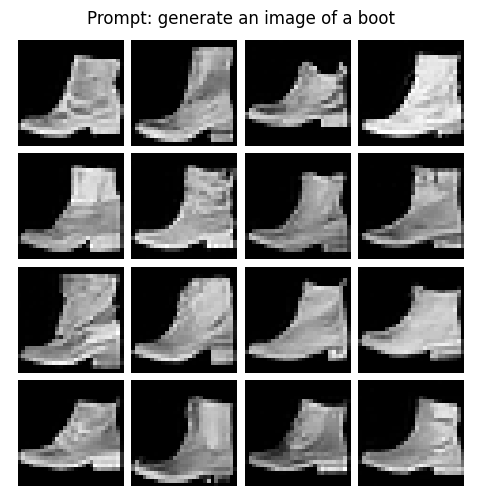

guided text diffusion:   0%|          | 0/300 [00:00<?, ?it/s]

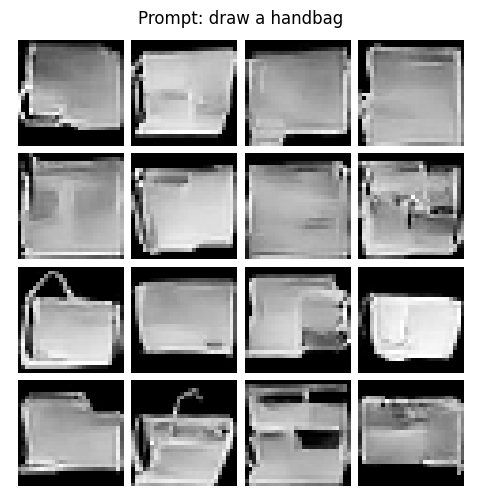

guided text diffusion:   0%|          | 0/300 [00:00<?, ?it/s]

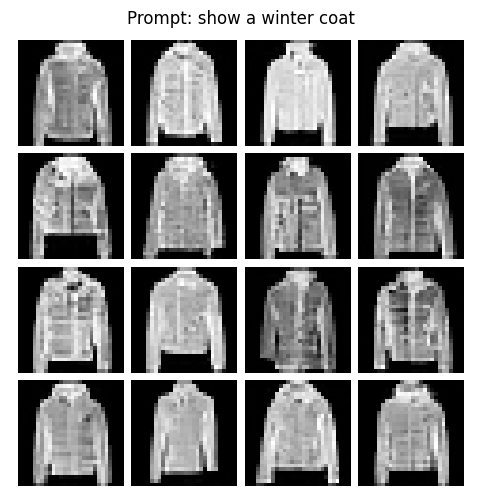

In [10]:
for title, prompts in [
    ("Prompt: generate an image of a boot", ["generate an image of a boot"] * 16),
    ("Prompt: draw a handbag", ["draw a handbag"] * 16),
    ("Prompt: show a winter coat", ["show a winter coat"] * 16),
]:
    samples = guided_text_sample(text_denoiser, prompts, guidance_scale=4.0)
    plt.figure(figsize=(6, 6))
    plt.imshow(utils.make_grid(samples.cpu(), nrow=4, pad_value=1.0).permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()


guided text diffusion:   0%|          | 0/300 [00:00<?, ?it/s]

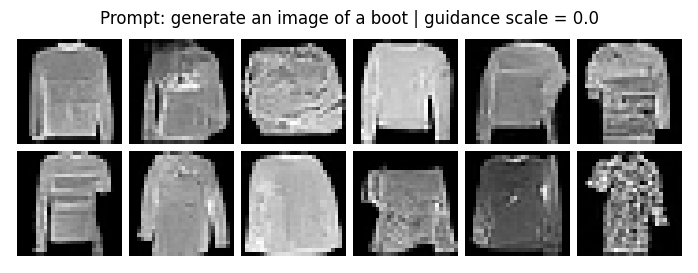

guided text diffusion:   0%|          | 0/300 [00:00<?, ?it/s]

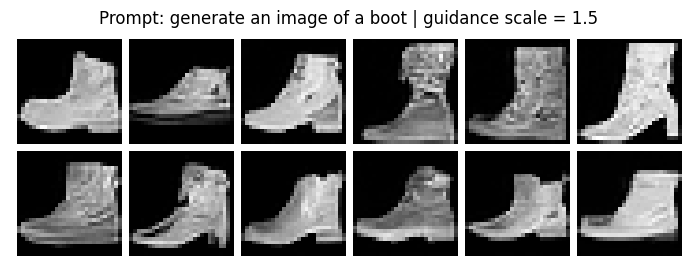

guided text diffusion:   0%|          | 0/300 [00:00<?, ?it/s]

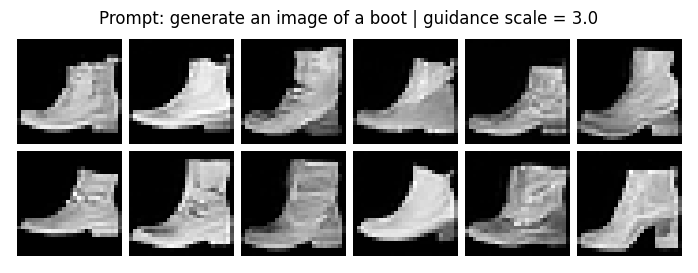

guided text diffusion:   0%|          | 0/300 [00:00<?, ?it/s]

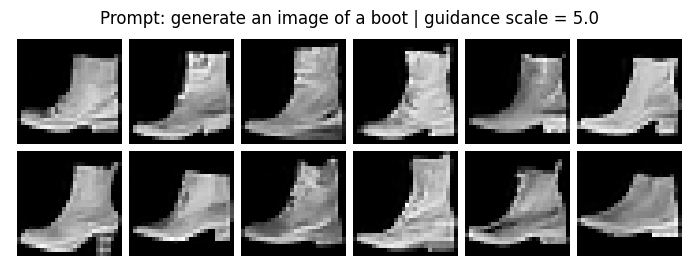

In [11]:
prompt = ["generate an image of a boot"] * 12
for scale in [0.0, 1.5, 3.0, 5.0]:
    samples = guided_text_sample(text_denoiser, prompt, guidance_scale=scale)
    plt.figure(figsize=(9, 3))
    plt.imshow(utils.make_grid(samples.cpu(), nrow=6, pad_value=1.0).permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.title(f"Prompt: generate an image of a boot | guidance scale = {scale}")
    plt.show()


### Batched FID and KID for Prompted Pixel-Space Diffusion

The quantitative evaluation keeps the same prompt distribution used during training. Real-image features are accumulated once, while fake images are generated in manageable batches, so the metric computation remains memory-safe.

In [12]:
def prepare_for_metrics(images):
    if images.size(1) == 1:
        images = images.repeat(1, 3, 1, 1)
    return images.clamp(0.0, 1.0)


def sample_random_prompts(batch_n):
    prompts = []
    for _ in range(batch_n):
        label = random.randrange(len(prompt_bank))
        prompts.append(random.choice(prompt_bank[label]))
    return prompts


@torch.no_grad()
def compute_prompt_metrics(sample_fn, real_loader, num_fake=1000, metric_batch_size=64):
    fid = FrechetInceptionDistance(feature=2048, normalize=True, reset_real_features=False).to(device)
    kid = KernelInceptionDistance(subset_size=50, normalize=True, reset_real_features=False).to(device)

    real_seen = 0
    for images, _, _ in tqdm(real_loader, desc="real features", leave=False):
        images = images.to(device)
        if real_seen >= num_fake:
            break
        current = min(images.size(0), num_fake - real_seen)
        real_batch = prepare_for_metrics(0.5 * (images[:current] + 1.0))
        fid.update(real_batch, real=True)
        kid.update(real_batch, real=True)
        real_seen += current

    fake_seen = 0
    while fake_seen < num_fake:
        batch_n = min(metric_batch_size, num_fake - fake_seen)
        fake_images = sample_fn(sample_random_prompts(batch_n)).to(device)
        fake_batch = prepare_for_metrics(fake_images)
        fid.update(fake_batch, real=False)
        kid.update(fake_batch, real=False)
        fake_seen += batch_n

    kid_mean, kid_std = kid.compute()
    return {
        "fid": float(fid.compute().item()),
        "kid_mean": float(kid_mean.item()),
        "kid_std": float(kid_std.item()),
    }


In [13]:
pixel_prompt_metrics = compute_prompt_metrics(
    lambda prompts: guided_text_sample(text_denoiser, prompts, guidance_scale=4.0, show_progress=False),
    prompt_test_loader,
    num_fake=1000,
    metric_batch_size=metric_batch_size,
)
pixel_prompt_metrics


c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


real features:   0%|          | 0/79 [00:00<?, ?it/s]

{'fid': 44.040035247802734,
 'kid_mean': 0.006761453114449978,
 'kid_std': 0.0035809935070574284}

## Latent Diffusion with a Variational Autoencoder

A latent diffusion model does not denoise pixels directly. It denoises the latent representation produced by a separate generative model. Using a **VAE** is natural because the latent space is already organized probabilistically: the encoder maps images to a Gaussian posterior, the decoder maps latent samples back to image space, and the latent prior encourages a structured sampling geometry. Diffusion can then operate in that representation rather than on the original pixel grid.

This changes the computational problem substantially. The denoiser no longer has to model local pixel correlations at full spatial resolution. It works on a smaller latent tensor whose structure has already been partially regularized by the VAE. The cost of sampling drops, while the decoder is responsible for turning the final latent sample into an image. In modern systems, this is one of the key reasons prompted generation becomes practical at larger resolutions.

Running diffusion in the latent space of an autoencoding model is the practical recipe popularized by latent diffusion models {cite}`rombach2022high`.

### Training a Convolutional VAE on FashionMNIST

The VAE below provides the latent space for the diffusion model. It is trained with a reconstruction term and a KL regularizer, exactly as in the earlier VAE notebook, but in a compact convolutional form suited to `FashionMNIST`. What matters here is not only that it reconstructs images reasonably well, but also that its latent representation becomes stable enough for a diffusion model to denoise inside it.

In [14]:
class ConvVAE(nn.Module):
    def __init__(self, latent_channels=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.SiLU(),
        )
        self.mu_head = nn.Conv2d(128, latent_channels, kernel_size=3, padding=1)
        self.logvar_head = nn.Conv2d(128, latent_channels, kernel_size=3, padding=1)
        self.decoder = nn.Sequential(
            nn.Conv2d(latent_channels, 128, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Tanh(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu_head(h), self.logvar_head(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        noise = torch.randn_like(std)
        return mu + std * noise

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


vae = ConvVAE(latent_channels=latent_channels).to(device)


In [15]:
def vae_loss(x, recon, mu, logvar, beta=1e-4):
    recon_loss = F.l1_loss(recon, x) + F.mse_loss(recon, x)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss, kl


vae_optimizer = torch.optim.Adam(vae.parameters(), lr=2e-4)
vae_history = []
base_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=(device.type == "cuda"))
base_test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(device.type == "cuda"))

for epoch in range(vae_epochs):
    vae.train()
    running = 0.0
    progress = tqdm(base_train_loader, desc=f"vae epoch {epoch + 1}/{vae_epochs}", leave=False)
    for images, _ in progress:
        images = images.to(device)
        recon, mu, logvar = vae(images)
        loss, recon_loss, kl = vae_loss(images, recon, mu, logvar)

        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()

        running += loss.item() * images.size(0)
        progress.set_postfix(recon=f"{recon_loss.item():.4f}", kl=f"{kl.item():.4f}")

    epoch_loss = running / len(base_train_loader.dataset)
    vae_history.append(epoch_loss)
    print(f"epoch {epoch + 1:02d} | vae loss = {epoch_loss:.4f}")

torch.save(vae.state_dict(), artifacts_dir / "fashionmnist_ldm_vae.pt")


vae epoch 1/35:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 01 | vae loss = 0.3293


vae epoch 2/35:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 02 | vae loss = 0.1390


vae epoch 3/35:   0%|          | 0/469 [00:00<?, ?it/s]

...

epoch 33 | vae loss = 0.0391


vae epoch 34/35:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 34 | vae loss = 0.0386


vae epoch 35/35:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 35 | vae loss = 0.0381


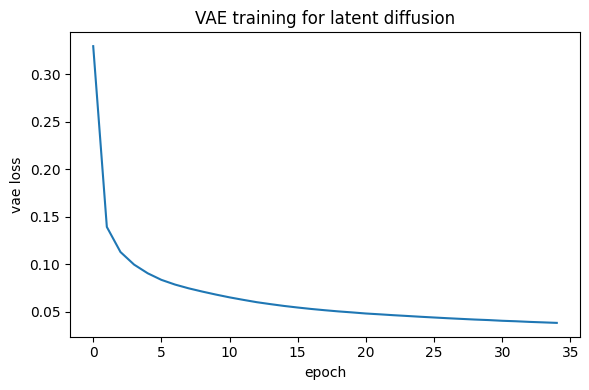

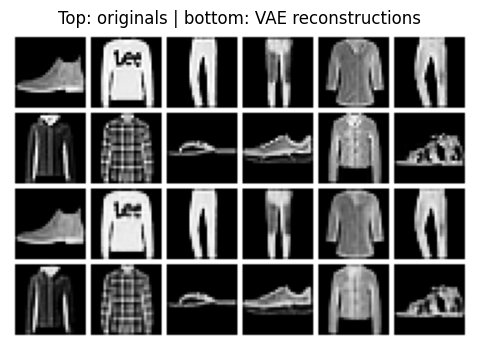

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(vae_history)
plt.xlabel("epoch")
plt.ylabel("vae loss")
plt.title("VAE training for latent diffusion")
plt.tight_layout()
plt.show()

vae.eval()
images, _ = next(iter(base_test_loader))
images = images[:12].to(device)
with torch.no_grad():
    recon, mu, logvar = vae(images)

visual = torch.cat([0.5 * (images + 1.0), 0.5 * (recon + 1.0)], dim=0)
plt.figure(figsize=(10, 4))
plt.imshow(utils.make_grid(visual.cpu(), nrow=6, pad_value=1.0).permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Top: originals | bottom: VAE reconstructions")
plt.show()


### Text-Conditioned Diffusion in VAE Latent Space

The latent denoiser uses the same pretrained prompt embeddings as the pixel-space model, but it now operates on latent tensors produced by the VAE encoder. The VAE mean is scaled before diffusion so that the latent magnitudes remain numerically well behaved. After the reverse process finishes, the final latent sample is decoded back to image space by the VAE decoder. This is the full latent diffusion pattern in compact form: a text encoder provides semantic conditioning, a diffusion model shapes latent samples, and a VAE decoder turns them into images.

In [20]:
class LatentTextConditionedUNet(nn.Module):
    def __init__(self, latent_channels=8, base_channels=96, time_dim=128, text_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.input_conv = nn.Conv2d(latent_channels, base_channels, kernel_size=3, padding=1)
        self.down1 = ConditionalResidualBlock(base_channels, base_channels, time_dim)
        self.downsample = nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.mid1 = ConditionalResidualBlock(base_channels * 2, base_channels * 2, time_dim)
        self.mid2 = ConditionalResidualBlock(base_channels * 2, base_channels * 2, time_dim)
        self.upsample = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1, output_padding=1)
        self.up1 = ConditionalResidualBlock(base_channels * 2, base_channels, time_dim)
        self.output_conv = nn.Conv2d(base_channels, latent_channels, kernel_size=3, padding=1)

    def forward(self, z, t, prompt_embedding):
        time_context = self.time_mlp(t)
        text_context = self.text_proj(prompt_embedding)
        context = time_context + text_context
        z0 = self.input_conv(z)
        z1 = self.down1(z0, context)
        z2 = self.downsample(z1)
        z2 = self.mid1(z2, context)
        z2 = self.mid2(z2, context)
        z3 = self.upsample(z2)
        z3 = torch.cat([z3, z1], dim=1)
        z3 = self.up1(z3, context)
        return self.output_conv(z3)


latent_denoiser = LatentTextConditionedUNet(latent_channels=latent_channels, base_channels=96, time_dim=time_dim, text_dim=text_dim).to(device)


In [21]:
@torch.no_grad()
def encode_latents(images):
    mu, logvar = vae.encode(images)
    return mu / latent_scaling


def latent_diffusion_loss(model, images, prompts):
    with torch.no_grad():
        latents = encode_latents(images)
        prompt_embedding = encode_prompts(apply_prompt_dropout(prompts, dropout_prob=condition_dropout))
    t = torch.randint(0, timesteps, (images.size(0),), device=images.device).long()
    noise = torch.randn_like(latents)
    zt = q_sample(latents, t, noise=noise)
    pred_noise = model(zt, t, prompt_embedding)
    return F.mse_loss(pred_noise, noise)


In [22]:
latent_optimizer = torch.optim.Adam(latent_denoiser.parameters(), lr=2e-4)
latent_history = []
vae.eval()

for epoch in range(latent_diffusion_epochs):
    latent_denoiser.train()
    running = 0.0
    progress = tqdm(prompt_train_loader, desc=f"latent diffusion epoch {epoch + 1}/{latent_diffusion_epochs}", leave=False)
    for images, labels, prompts in progress:
        images = images.to(device)
        loss = latent_diffusion_loss(latent_denoiser, images, prompts)

        latent_optimizer.zero_grad()
        loss.backward()
        latent_optimizer.step()

        running += loss.item() * images.size(0)
        progress.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running / len(prompt_train_loader.dataset)
    latent_history.append(epoch_loss)
    print(f"epoch {epoch + 1:02d} | latent diffusion loss = {epoch_loss:.4f}")

torch.save(latent_denoiser.state_dict(), artifacts_dir / "fashionmnist_latent_text_diffusion.pt")


latent diffusion epoch 1/45:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 01 | latent diffusion loss = 0.8790


latent diffusion epoch 2/45:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 02 | latent diffusion loss = 0.6844


latent diffusion epoch 3/45:   0%|          | 0/469 [00:00<?, ?it/s]

...

epoch 43 | latent diffusion loss = 0.4412


latent diffusion epoch 44/45:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 44 | latent diffusion loss = 0.4396


latent diffusion epoch 45/45:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 45 | latent diffusion loss = 0.4389


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(latent_history)
plt.xlabel("epoch")
plt.ylabel("latent noise prediction loss")
plt.title("Latent diffusion training")
plt.tight_layout()
plt.show()


### Sampling from Text Prompts in Latent Space

The latent sampler mirrors the pixel-space sampler, except that the reverse process runs on latent tensors and the final denoised latent is decoded by the VAE. Using the same prompt embeddings in both settings makes the comparison between pixel-space and latent-space denoising particularly transparent.

In [ ]:
@torch.no_grad()
def guided_latent_text_sample(model, prompts, guidance_scale=4.0, show_progress=True):
    model.eval()
    vae.eval()
    cond_embedding = encode_prompts(prompts)
    uncond_embedding = encode_prompts([null_prompt] * len(prompts))

    z = torch.randn(len(prompts), latent_channels, 7, 7, device=device)
    reverse_steps = reversed(range(timesteps))
    if show_progress:
        reverse_steps = tqdm(reverse_steps, total=timesteps, desc="guided latent diffusion", leave=False)

    for t_scalar in reverse_steps:
        t = torch.full((len(prompts),), t_scalar, device=device, dtype=torch.long)
        eps_cond = model(z, t, cond_embedding)
        eps_uncond = model(z, t, uncond_embedding)
        pred_noise = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        beta_t = extract(betas, t, z.shape)
        sqrt_one_minus_alpha_t = extract(sqrt_one_minus_alphas, t, z.shape)
        sqrt_recip_bar_alpha_t = extract(sqrt_recip_bar_alphas, t, z.shape)
        model_mean = sqrt_recip_bar_alpha_t * (z - beta_t * pred_noise / sqrt_one_minus_alpha_t)

        if t_scalar > 0:
            variance = extract(posterior_variance, t, z.shape)
            z = model_mean + torch.sqrt(variance) * torch.randn_like(z)
        else:
            z = model_mean

    decoded = vae.decode(z * latent_scaling).clamp(-1, 1)
    return 0.5 * (decoded + 1.0)


In [ ]:
for title, prompts in [
    ("Latent diffusion prompt: generate an image of a boot", ["generate an image of a boot"] * 16),
    ("Latent diffusion prompt: draw a handbag", ["draw a handbag"] * 16),
]:
    samples = guided_latent_text_sample(latent_denoiser, prompts, guidance_scale=4.0)
    plt.figure(figsize=(6, 6))
    plt.imshow(utils.make_grid(samples.cpu(), nrow=4, pad_value=1.0).permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()


In [ ]:
comparison_prompts = [
    "generate an image of a boot",
    "generate an image of a dress",
    "draw a handbag",
    "show a winter coat",
] * 4

pixel_samples = guided_text_sample(text_denoiser, comparison_prompts, guidance_scale=4.0, show_progress=False)
latent_samples = guided_latent_text_sample(latent_denoiser, comparison_prompts, guidance_scale=4.0, show_progress=False)

for title, samples in [
    ("Pixel-space text-conditioned diffusion", pixel_samples),
    ("Latent diffusion with the same prompts", latent_samples),
]:
    plt.figure(figsize=(10, 4))
    plt.imshow(utils.make_grid(samples.cpu(), nrow=4, pad_value=1.0).permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()


### Batched FID and KID for Latent Diffusion

The latent model is evaluated with the same prompt distribution as the pixel-space model. The metric code stays unchanged except for the sampling function.

In [ ]:
latent_prompt_metrics = compute_prompt_metrics(
    lambda prompts: guided_latent_text_sample(latent_denoiser, prompts, guidance_scale=4.0, show_progress=False),
    prompt_test_loader,
    num_fake=1000,
    metric_batch_size=metric_batch_size,
)
latent_prompt_metrics
